## Mini-BLIP2 数据输入层

In [41]:
import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import pandas as pd
import os

import matplotlib.pyplot as plt
from datetime import datetime

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [42]:
class Flickr8kDataset(Dataset):

    def __init__(self, captions_file, image_dir, transform=None):

        self.df = pd.read_csv(captions_file)

        # 只取前200
        self.df = self.df.iloc[:500]

        self.image_dir = image_dir

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        image_name = self.df.iloc[idx]['image']

        caption = self.df.iloc[idx]['caption']

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, caption, image_path

In [43]:
dataset = Flickr8kDataset(
    captions_file="data1/captions.txt",
    image_dir="data1/Images",
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

## CLIP 图像编码器阶段

In [44]:
from transformers import CLIPProcessor, CLIPModel

In [45]:
import os

print(os.getcwd())

e:\Ashenduxx\blip2-main\ztry


In [46]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained(
    "./clip-vit-base-patch32",
    local_files_only=True
)

clip_processor = CLIPProcessor.from_pretrained(
    "./clip-vit-base-patch32",
    local_files_only=True
)

print("CLIP加载成功")

CLIP加载成功


In [47]:
for param in clip_model.parameters():
    param.requires_grad = False

In [48]:
import pandas as pd

caption_path = "data1/captions.txt"

captions_df = pd.read_csv(caption_path)

captions_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [49]:
image_name = captions_df.iloc[0]['image']

print(image_name)

1000268201_693b08cb0e.jpg


(-0.5, 374.5, 499.5, -0.5)

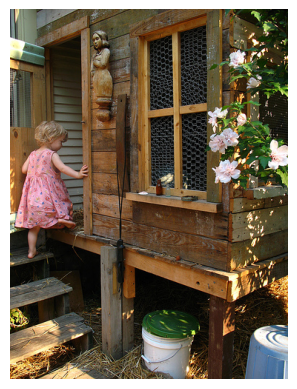

In [50]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_path = os.path.join(
    "data1/Images",
    image_name
)

pil_image = Image.open(image_path).convert("RGB")

plt.imshow(pil_image)
plt.axis("off")

In [51]:
inputs = clip_processor(
    images=pil_image,
    return_tensors="pt"
)

In [52]:
import torch

with torch.no_grad():

    image_features = clip_model.get_image_features(
        **inputs
    )

print(image_features.shape)

torch.Size([1, 512])


## Mini Q-Former

In [53]:
import torch.nn as nn

class MiniQFormer(nn.Module):

    def __init__(
        self,
        embed_dim=512,
        num_queries=8,
        num_layers=2,
        num_heads=8
    ):

        super().__init__()

        # 可学习 Query Tokens
        self.query_tokens = nn.Parameter(
            torch.randn(1, num_queries, embed_dim)
        )

        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        # Transformer Encoder
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

    def forward(self, image_features):

        batch_size = image_features.shape[0]

        # 扩展 query tokens
        queries = self.query_tokens.expand(
            batch_size,
            -1,
            -1
        )

        # 拼接 image feature
        image_features = image_features.unsqueeze(1)

        x = torch.cat(
            [queries, image_features],
            dim=1
        )

        # Transformer
        output = self.transformer(x)

        #return output  改
        return output[:, :-1, :]  #改

In [54]:
qformer = MiniQFormer()

print(qformer)

MiniQFormer(
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
)


In [55]:
image_features.shape

torch.Size([1, 512])

In [56]:
q_output = qformer(image_features)

print(q_output.shape)

torch.Size([1, 8, 512])


In [57]:
projection = nn.Linear(
    512,
    768
)

projected_features = projection(q_output)

print(projected_features.shape)

torch.Size([1, 8, 768])


In [58]:
from transformers import AutoTokenizer, OPTForCausalLM

tokenizer = AutoTokenizer.from_pretrained(
    "./opt-125m",
    local_files_only=True
)

opt_model = OPTForCausalLM.from_pretrained(
    "./opt-125m",
    local_files_only=True
)

print("OPT加载成功")

# 配置 tokenizer 的 special tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.pad_token = tokenizer.eos_token
opt_model.config.pad_token_id = tokenizer.pad_token_id
opt_model.config.eos_token_id = tokenizer.eos_token_id

# 重新获取 embedding_layer（因为 tokenizer 可能变了）
embedding_layer = opt_model.get_input_embeddings()
print("Tokenizer 配置完成")

OPT加载成功
Tokenizer 配置完成


In [59]:
for param in opt_model.parameters():
    param.requires_grad = False

In [60]:
embedding_layer = opt_model.get_input_embeddings()

In [61]:
prompt = "A photo of"

In [62]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

In [63]:
prompt_embeddings = embedding_layer(
    inputs.input_ids
)

In [64]:
print(prompt_embeddings.shape)

torch.Size([1, 3, 768])


In [65]:
combined_embeddings = torch.cat(
    [
        projected_features,
        prompt_embeddings
    ],
    dim=1
)

In [66]:
print(combined_embeddings.shape)

torch.Size([1, 11, 768])


In [67]:
generated_ids = opt_model.generate(

    inputs_embeds=combined_embeddings,

    max_length=30,

    do_sample=False,

    top_k=50
)
generated_text = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True
)

In [68]:
generated_text = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True
)

print(generated_text)

 the same day.

The following day, the two men are in the same time,


## 训练

In [69]:
optimizer = torch.optim.Adam(

    list(qformer.parameters()) +
    list(projection.parameters()),

    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

In [70]:
# =========================
# DataLoader
# =========================
dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

# =========================
# device
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

# =========================
# 模型放到 device
# =========================
clip_model.to(device)
qformer.to(device)
projection.to(device)
opt_model.to(device)

# train mode
qformer.train()
projection.train()
opt_model.train()

# =========================
# optimizer
# =========================
optimizer = torch.optim.Adam(
    list(qformer.parameters()) +
    list(projection.parameters()),
    lr=1e-4
)

# =========================
# 保存loss历史
# =========================
loss_history = []
epoch_losses = []

# =========================
# 创建保存模型文件夹
# =========================
os.makedirs("./checkpoints", exist_ok=True)

# =========================
# epoch
# =========================
epochs = 50

for epoch in range(epochs):

    total_loss = 0
    num_batches = 0

    for batch in dataloader:
        images, captions, image_paths = batch
        batch_size = len(captions)

        # =========================
        # Batch CLIP
        # =========================
        pil_images = [
            Image.open(p).convert("RGB")
            for p in image_paths
        ]

        clip_inputs = clip_processor(
            images=pil_images,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():

            image_features = clip_model.get_image_features(
                **clip_inputs
            )

        # =========================
        # QFormer
        # =========================
        q_output = qformer(image_features)

        # =========================
        # Projection
        # =========================
        projected_features = projection(q_output)

        # =========================
        # tokenizer
        # =========================
        captions_with_prompt = [
            "A photo of " + c
            for c in captions
        ]
        
        text_inputs = tokenizer(
            captions_with_prompt,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        input_ids = text_inputs.input_ids

        # =========================
        # embedding
        # =========================
        embedding_layer = opt_model.get_input_embeddings()

        with torch.no_grad():
            text_embeddings = embedding_layer(
                input_ids
            )

        # =========================
        # concat
        # =========================
        inputs_embeds = torch.cat(
            [projected_features, text_embeddings],
            dim=1
        )

        # =========================
        # labels
        # =========================
        labels = input_ids.clone()

        pad = torch.full(
            (
                batch_size,
                projected_features.shape[1]
            ),
            -100
        ).to(device)
        labels = torch.cat(
            [pad, labels],
            dim=1
        )

        # attention mask
        attention_mask = torch.cat(
            [
                torch.ones(
                    batch_size,
                    projected_features.shape[1]
                ).to(device),
                text_inputs.attention_mask
            ],
            dim=1
        )

        # =========================
        # forward
        # =========================
        outputs = opt_model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        # =========================
        # backward
        # =========================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # =========================
        # loss统计
        # =========================
        total_loss += loss.item()
        num_batches += 1
        loss_history.append(
            loss.item()
        )

    # =========================
    # epoch loss
    # =========================
    avg_loss = total_loss / num_batches
    epoch_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {avg_loss:.4f}"
    )

    # =========================
    # 保存 checkpoint
    # =========================
    if (epoch + 1) % 5 == 0:

        torch.save(
            {
                'epoch': epoch,
                'model_state_dict':
                qformer.state_dict(),
                'projection_state_dict':
                projection.state_dict(),
                'optimizer_state_dict':
                optimizer.state_dict(),
                'loss': avg_loss,
            },

            f"./checkpoints/"
            f"checkpoint_epoch_{epoch+1}.pt"
        )

        print(
            f"✅ 已保存 "
            f"checkpoint_epoch_{epoch+1}.pt"
        )

# =========================
# 保存最终模型
# =========================
torch.save(
    {
        'qformer_state_dict':
        qformer.state_dict(),
        'projection_state_dict':
        projection.state_dict(),
        'epoch_losses':
        epoch_losses,
        'loss_history':
        loss_history,
    },

    "./checkpoints/mini_blip2_final.pt"
)

print(
    "✅ 最终模型已保存到 "
    "./checkpoints/mini_blip2_final.pt"
)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


cpu
Epoch 1/10 Loss: 2.7063
Epoch 2/10 Loss: 2.1246
Epoch 3/10 Loss: 2.0421
Epoch 4/10 Loss: 1.9717
Epoch 5/10 Loss: 1.8612
✅ 已保存 checkpoint_epoch_5.pt
Epoch 6/10 Loss: 1.7663
Epoch 7/10 Loss: 1.6266
Epoch 8/10 Loss: 1.5561
Epoch 9/10 Loss: 1.4924
Epoch 10/10 Loss: 1.4234
✅ 已保存 checkpoint_epoch_10.pt
✅ 最终模型已保存到 ./checkpoints/mini_blip2_final.pt


C:\Users\ZHX_LAPTOP\AppData\Local\Temp\ipykernel_30776\2894799823.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./checkpoints/mini_blip2_fina

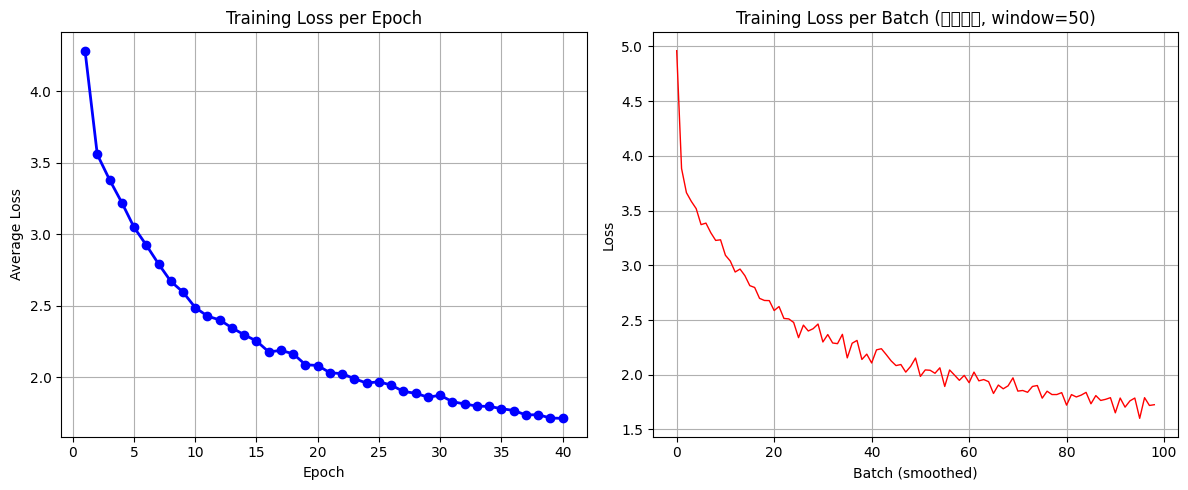

📊 Loss曲线已保存到 ./checkpoints/training_loss_curve.png


In [32]:
# ============ 绘制loss曲线（单独运行）============

import matplotlib.pyplot as plt
import numpy as np

# 方法1：从内存中绘制（如果刚训练完，变量还在）
# 如果变量还在内存中，直接使用 epoch_losses 和 loss_history

# 方法2：从保存的文件中加载（推荐，可以随时运行）
# 如果重新打开了 notebook，用这个方法加载
checkpoint = torch.load("./checkpoints/mini_blip2_final.pt", map_location='cpu')
epoch_losses = checkpoint['epoch_losses']
loss_history = checkpoint['loss_history']

# 绘制
plt.figure(figsize=(12, 5))

# 子图1：每个epoch的平均loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)

# 子图2：每个batch的loss（滑动平均）
plt.subplot(1, 2, 2)
window_size = min(50, len(loss_history) // 10)  # 动态调整窗口大小
smoothed_loss = [sum(loss_history[i:i+window_size])/window_size 
                  for i in range(0, len(loss_history)-window_size, window_size)]
plt.plot(smoothed_loss, 'r-', linewidth=1)
plt.xlabel('Batch (smoothed)')
plt.ylabel('Loss')
plt.title(f'Training Loss per Batch (滑动平均, window={window_size})')
plt.grid(True)

plt.tight_layout()
plt.savefig("./checkpoints/training_loss_curve.png", dpi=150)
plt.show()

print("📊 Loss曲线已保存到 ./checkpoints/training_loss_curve.png")

Real Caption:
A man in an orange hat starring at something .


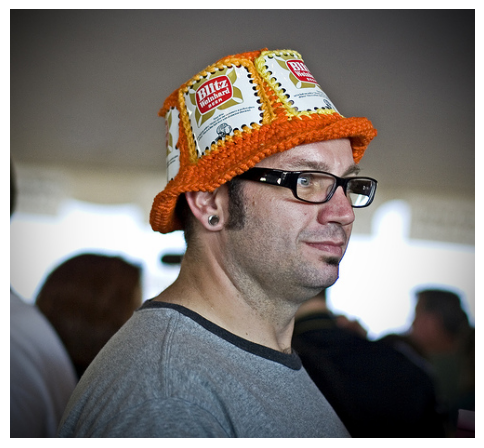

In [71]:
# 选择测试图片
test_idx = 20

image, real_caption, image_path = dataset[test_idx]

# 显示图片
pil_image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(pil_image)
plt.axis("off")

print("Real Caption:")
print(real_caption)

In [72]:
# ===== CLIP =====

clip_inputs = clip_processor(
    images=pil_image,
    return_tensors="pt"
).to(device)

with torch.no_grad():

    image_features = clip_model.get_image_features(
        **clip_inputs
    )

# ===== QFormer =====

with torch.no_grad():

    q_output = qformer(
        image_features
    )

# ===== Projection =====

with torch.no_grad():

    projected_features = projection(
        q_output
    )

# prompt
prompt = "A photo of"

text_inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(device)

prompt_embeds = embedding_layer(
    text_inputs.input_ids
)

inputs_embeds = torch.cat(
    [projected_features, prompt_embeds],
    dim=1
)

In [73]:
# 单元格 89 - 完全重写
generated_ids = opt_model.generate(
    inputs_embeds=inputs_embeds,
    max_new_tokens=20,  # 使用 max_new_tokens 而不是 max_length
    min_length=5,
    do_sample=True,
    temperature=0.6,
    top_k=50,
    top_p=0.85,
    repetition_penalty=1.5,  # 增大惩罚系数
    no_repeat_ngram_size=3,  # 禁止重复3-gram
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
    early_stopping=True,
    num_beams=1  # 不启用 beam search，避免重复
)

e:\Anaconda\envs\GP\lib\site-packages\transformers\generation\configuration_utils.py:638: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


In [74]:
# 单元格 90 - 加强清理
generated_text = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True  # 添加这个参数
)

# 移除 prompt 部分
prompt = "A photo of"
if generated_text.startswith(prompt):
    generated_text = generated_text[len(prompt):].strip()

# 清理乱码和特殊字符
import re
# 移除乱码字符（非字母、数字、空格、标点）
generated_text = re.sub(r'[^\w\s\.\,\!\?\'\"]+', '', generated_text)
# 只取第一句
generated_text = re.split(r'[.!?]', generated_text)[0]
# 限制长度
if len(generated_text) > 60:
    generated_text = generated_text[:60]

print("Generated Caption:")
print(generated_text)

# 后处理函数
def clean_generated_text(text):
    """清理生成的文本"""
    # 移除各种乱码模式
    import re
    
    # 移除 HTML/XML 标签
    text = re.sub(r'<[^>]+>', '', text)
    
    # 移除特殊 token 模式
    text = re.sub(r'<s>|</s>|<pad>|<unk>|\[[A-Z]+\]', '', text)
    
    # 移除乱码单词（包含数字或特殊符号的）
    text = re.sub(r'\b\w*\d+\w*\b', '', text)
    
    # 只保留字母、空格和基本标点
    text = re.sub(r'[^a-zA-Z\s\.\,\!\?\'\"]+', '', text)
    
    # 移除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 只取第一句
    text = re.split(r'[.!?]', text)[0]
    
    # 首字母大写
    if text:
        text = text[0].upper() + text[1:]
    
    return text

# 使用清理函数
cleaned = clean_generated_text(generated_text)
print("Generated Caption (cleaned):")
print(cleaned)

Generated Caption:
 A man wearing a hat with glasses
Generated Caption (cleaned):
A man wearing a hat with glasses


模型推理测试


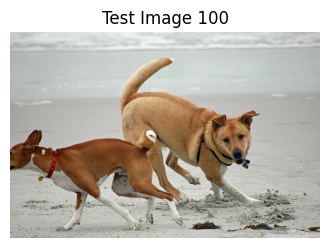

📷 图片: Images\1024138940_f1fefbdce1.jpg
📝 真实描述: Two different breeds of brown and white dogs play on the beach .
🤖 生成描述:  Two dogs playing on the beach.
--------------------------------------------------


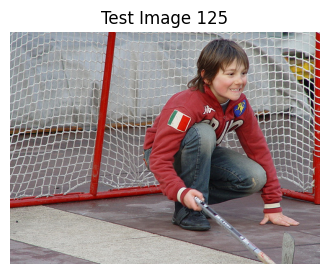

📷 图片: Images\103106960_e8a41d64f8.jpg
📝 真实描述: A boy with a stick kneeling in front of a goalie net
🤖 生成描述:  A girl in a hockey uniform is standing at the end of her skateboard.
--------------------------------------------------


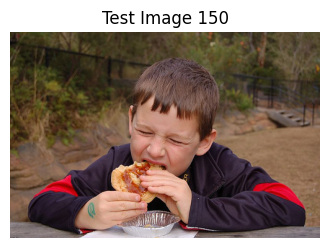

📷 图片: Images\1034276567_49bb87c51c.jpg
📝 真实描述: A boy bites hard into a treat while he sits outside .
🤖 生成描述:  A small boy is eating food on a outdoor area.
--------------------------------------------------


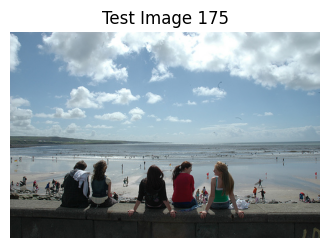

📷 图片: Images\1048710776_bb5b0a5c7c.jpg
📝 真实描述: a couple of several people sitting on a ledge overlooking the beach
🤖 生成描述:  a group of people at the beach.
--------------------------------------------------


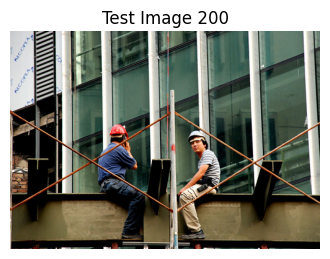

📷 图片: Images\1055753357_4fa3d8d693.jpg
📝 真实描述: Two constructions workers sit on a beam taking a break .
🤖 生成描述:  Two construction workers are building a steel structure on the waterfront.
--------------------------------------------------


In [79]:
# ============ 推理函数 ============

def generate_caption(
    image_path,
    qformer_model,
    proj_model,
    max_length=40   ####改
):

    # =========================
    # 加载图片
    # =========================
    pil_image = Image.open(
        image_path
    ).convert("RGB")

    # =========================
    # CLIP
    # =========================
    clip_inputs = clip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        image_features = clip_model.get_image_features(
            **clip_inputs
        )

    # =========================
    # QFormer
    # =========================
    with torch.no_grad():

        q_output = qformer_model(
            image_features
        )
        projected = proj_model(
            q_output
        )

    # =========================
    # Prompt
    # =========================
    prompt = "A photo of"
    text_inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    embedding_layer = (
        opt_model.get_input_embeddings()
    )

    with torch.no_grad():
        prompt_embeds = embedding_layer(
            text_inputs.input_ids
        )

    # batch 对齐
    prompt_embeds = prompt_embeds.expand(
        projected.shape[0],
        -1,
        -1
    )

    # =========================
    # 拼接
    # =========================
    inputs_embeds = torch.cat(
        [projected, prompt_embeds],
        dim=1
    )

    # =========================
    # Generate
    # =========================
    with torch.no_grad():
        generated_ids = opt_model.generate(
            inputs_embeds=inputs_embeds,
            max_new_tokens=35,
            do_sample=True,
            top_k=50,
            top_p=0.9,
            temperature=0.7,
            repetition_penalty=2.2,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.eos_token_id,
            bos_token_id=tokenizer.bos_token_id,
            pad_token_id=tokenizer.eos_token_id,
            early_stopping=True
        )

    caption = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )
    return caption


# ============ 测试多个样本 ============
#test_indices = [1, 5, 15, 20, 30]
test_indices = [100, 125, 150, 175, 200]
print("=" * 60)
print("模型推理测试")
print("=" * 60)

for idx in test_indices:
    image_tensor, real_caption, image_path = dataset[idx]

    # 显示图片
    pil_image = Image.open(
        image_path
    ).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(pil_image)
    plt.axis("off")
    plt.title(f"Test Image {idx}")
    plt.show()
    print(
        f"📷 图片: "
        f"{image_path.split('/')[-1]}"
    )
    print(
        f"📝 真实描述: "
        f"{real_caption}"
    )

    generated = generate_caption(
        image_path,
        qformer,
        projection
    )

    print(f"🤖 生成描述: {generated}")

    print("-" * 50)

##